# Social Media Performance Predictor
### Faro Safehouse — INTEX W26

**Business question:** Which content strategies (platform, post type, media format, topic, timing) drive the most donation referrals from social media?

**Why it matters:** Faro Safehouse posts across 7 platforms (Facebook, Instagram, Twitter, TikTok, YouTube, LinkedIn, WhatsApp). Staff time is limited — they need data-driven guidance on where to focus content creation effort for maximum fundraising impact.

**Problem type:** This is a **regression** problem, not classification — we predict a continuous count (`donation_referrals`).

**Dual-target approach:**
- **Primary model** predicts `donation_referrals` (direct fundraising impact).
- **Secondary model** predicts `engagement_rate` (audience resonance). The engagement rate model has an inherent limitation: `engagement_rate` is a post-publication metric (engagement/reach), so predicting it from pre-publication features has a ceiling on accuracy.

**Success metrics:** MAE (primary — interpretable in units of donation referrals), RMSE, R-squared, improvement over baseline.

In [72]:
%matplotlib inline

import json
import warnings
from datetime import datetime, timezone
from itertools import product
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Imports complete.")

from scipy import stats
from scipy.stats import probplot
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor


Imports complete.


---
## 1. Data Acquisition, Preparation & Exploration

### 1.1 Load Data

The dataset `social_media_posts.csv` contains 812 posts across 7 platforms collected from Faro Safehouse social media accounts.

In [73]:
df = pd.read_csv("data/social_media_posts.csv")
print(f"Loaded social_media_posts: {df.shape}")
df.head()

Loaded social_media_posts: (812, 39)


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN
3,380,Instagram,ig_4154485528046983,https://instagram.com/p/1LSXA225Jpv,2023-01-09 15:06:00,Monday,15,ThankYou,Video,Every donation is a prayer answered. Thank you...,...,3313.0,0.0677,62,0,0.00,1796,NaN,NaN,NaN,NaN
4,425,TikTok,tk_7166643297225195,https://tiktok.com/@lighthouse_ph/video/817153...,2023-01-09 15:59:00,Monday,15,ThankYou,Reel,Big thanks to Juan for the recent donation. Yo...,...,17974.0,0.0802,172,2,8351.49,916,NaN,NaN,NaN,NaN


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   post_id                       812 non-null    int64  
 1   platform                      812 non-null    str    
 2   platform_post_id              812 non-null    str    
 3   post_url                      812 non-null    str    
 4   created_at                    812 non-null    str    
 5   day_of_week                   812 non-null    str    
 6   post_hour                     812 non-null    int64  
 7   post_type                     812 non-null    str    
 8   media_type                    812 non-null    str    
 9   caption                       812 non-null    str    
 10  hashtags                      664 non-null    str    
 11  num_hashtags                  812 non-null    int64  
 12  mentions_count                812 non-null    int64  
 13  has_call_to_acti

In [75]:
df.describe()

,post_id,post_hour,num_hashtags,mentions_count,caption_length,boost_budget_php,impressions,reach,likes,comments,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
count,812.000000,812.000000,812.000000,812.000000,812.000000,127.000000,812.000000,812.000000,812.000000,812.000000,...,333.000000,812.000000,812.000000,812.000000,8.120000e+02,812.000000,7.100000e+01,71.000000,71.000000,93.000000
mean,406.500000,12.690887,2.046798,0.612069,137.318966,2430.143622,5701.841133,3683.612069,332.820197,89.917488,...,6989.051051,0.098980,126.262315,12.795567,3.977209e+04,1502.307882,1.876390e+06,178.183099,483.591549,97.752688
std,234.548502,6.296557,1.414310,0.853514,28.559851,1382.050980,6449.237083,4157.183390,511.794608,131.019673,...,6711.240871,0.055541,191.093579,31.261714,1.240811e+05,688.176221,2.525493e+06,152.988170,190.468113,218.364108
min,1.000000,0.000000,0.000000,0.000000,67.000000,203.890000,91.000000,66.000000,1.000000,0.000000,...,198.000000,0.013400,0.000000,0.000000,0.000000e+00,360.000000,1.732800e+04,15.000000,204.000000,0.000000
25%,203.750000,8.000000,1.000000,0.000000,121.000000,1185.195000,1530.000000,1005.750000,48.750000,13.000000,...,2220.000000,0.054600,18.000000,0.000000,0.000000e+00,916.000000,2.786850e+05,61.000000,325.500000,7.000000
50%,406.500000,13.000000,2.000000,0.000000,137.000000,2441.000000,3275.500000,2144.500000,147.500000,43.000000,...,4691.000000,0.089300,58.000000,2.000000,4.556955e+03,1543.000000,1.033405e+06,122.000000,478.000000,36.000000
75%,609.250000,18.000000,3.000000,1.000000,152.000000,3623.220000,7354.750000,4769.000000,391.250000,108.500000,...,10019.000000,0.136825,148.250000,11.000000,3.007207e+04,1833.000000,2.224055e+06,258.000000,617.500000,121.000000
max,812.000000,23.000000,5.000000,3.000000,220.000000,4966.980000,35920.000000,20000.000000,4942.000000,1061.000000,...,37110.000000,0.250000,1534.000000,458.000000,2.402436e+06,2489.000000,1.169815e+07,627.000000,898.000000,1930.000000


### 1.2 Exploratory Data Analysis

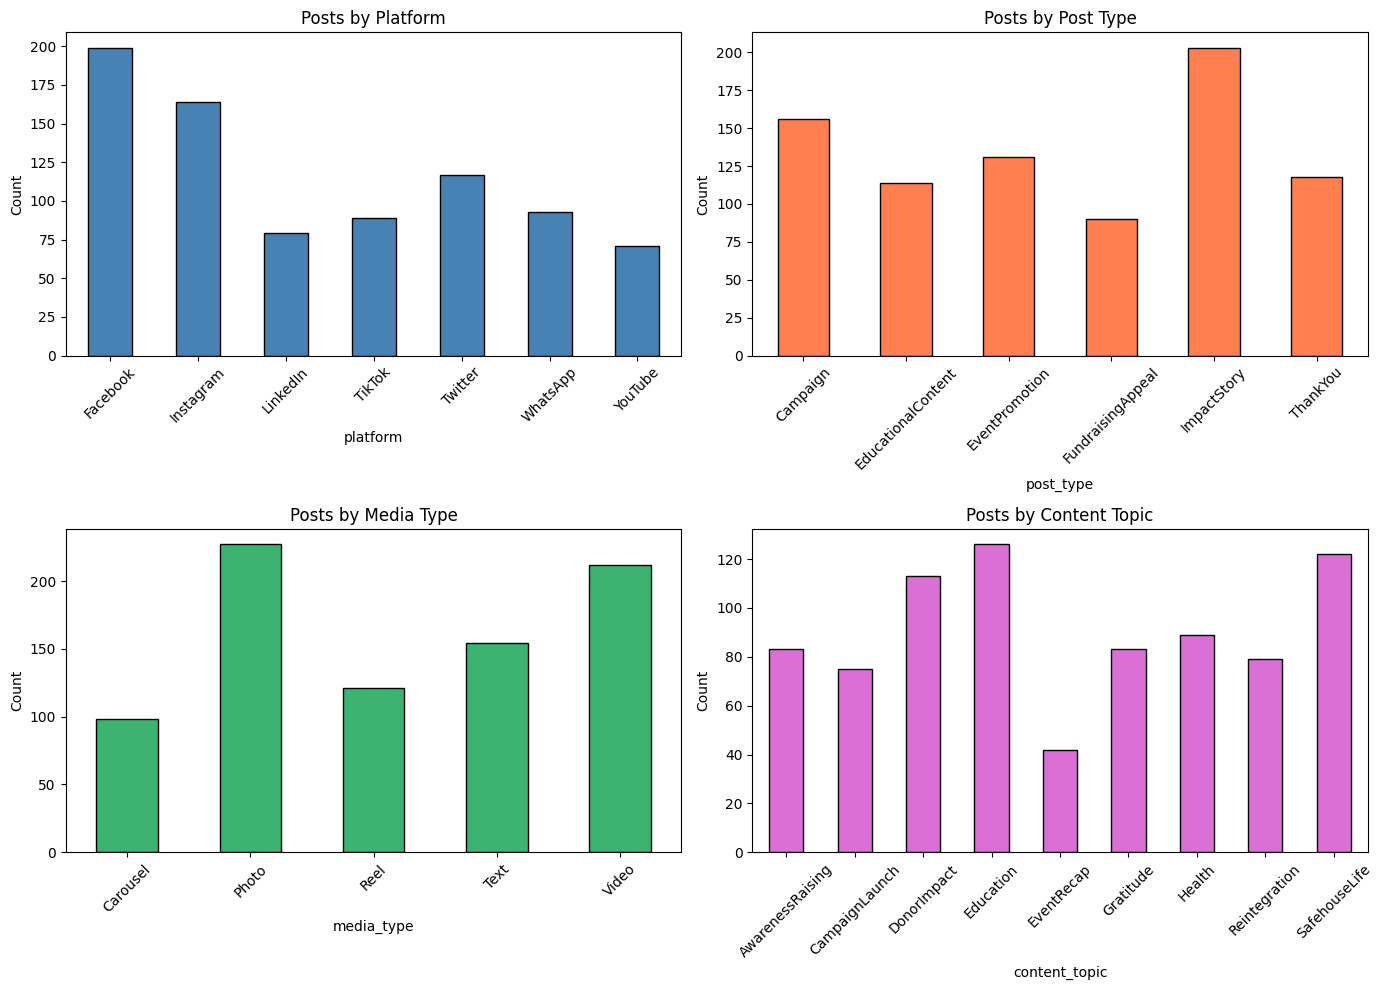

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Platform distribution
df["platform"].value_counts().sort_index().plot.bar(ax=axes[0, 0], color="steelblue", edgecolor="black")
axes[0, 0].set_title("Posts by Platform")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=45)

# Post type distribution
df["post_type"].value_counts().sort_index().plot.bar(ax=axes[0, 1], color="coral", edgecolor="black")
axes[0, 1].set_title("Posts by Post Type")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=45)

# Media type distribution
df["media_type"].value_counts().sort_index().plot.bar(ax=axes[1, 0], color="mediumseagreen", edgecolor="black")
axes[1, 0].set_title("Posts by Media Type")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis="x", rotation=45)

# Content topic distribution
df["content_topic"].value_counts().sort_index().plot.bar(ax=axes[1, 1], color="orchid", edgecolor="black")
axes[1, 1].set_title("Posts by Content Topic")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 1.3 Target Variable Analysis

The target `donation_referrals` is highly right-skewed (median=2, mean~12.8, max=458). About 35.7% of posts have zero referrals. This skewness drives up the MAE — a handful of viral posts dominate the upper tail.

/var/folders/vv/cg1ymphx6xz5qjjscmqrk51h0000gn/T/ipykernel_70780/1731161381.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_platform, labels=platforms_sorted, patch_artist=True)


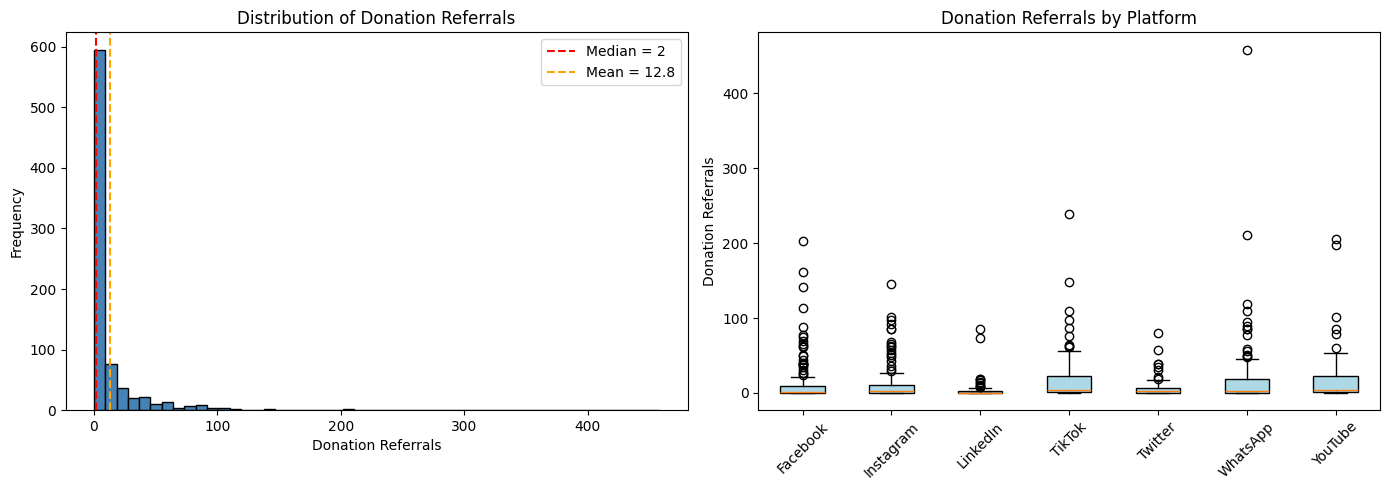

Target stats: median=2.0, mean=12.8, max=458
Zero-referral posts: 35.7%


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of donation_referrals
axes[0].hist(df["donation_referrals"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of Donation Referrals")
axes[0].set_xlabel("Donation Referrals")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["donation_referrals"].median(), color="red", linestyle="--",
                label=f"Median = {df['donation_referrals'].median():.0f}")
axes[0].axvline(df["donation_referrals"].mean(), color="orange", linestyle="--",
                label=f"Mean = {df['donation_referrals'].mean():.1f}")
axes[0].legend()

# Boxplot by platform
platforms_sorted = sorted(df["platform"].unique())
data_by_platform = [df[df["platform"] == p]["donation_referrals"].values for p in platforms_sorted]
bp = axes[1].boxplot(data_by_platform, labels=platforms_sorted, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue")
axes[1].set_title("Donation Referrals by Platform")
axes[1].set_ylabel("Donation Referrals")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Target stats: median={df['donation_referrals'].median()}, "
      f"mean={df['donation_referrals'].mean():.1f}, "
      f"max={df['donation_referrals'].max()}")
print(f"Zero-referral posts: {(df['donation_referrals'] == 0).mean():.1%}")

### 1.4 Platform-Media Type Validity

Not all media types exist on all platforms (e.g., YouTube only has Video and Reel). We use this mapping later for the recommendation grid to avoid generating impossible combinations.

In [78]:
platform_media = df.groupby(["platform", "media_type"]).size().reset_index(name="count")
print("Valid platform-media type combinations:")
print(platform_media.to_string(index=False))

Valid platform-media type combinations:
 platform media_type  count
 Facebook   Carousel     33
 Facebook      Photo     78
 Facebook       Reel      5
 Facebook       Text     28
 Facebook      Video     55
Instagram   Carousel     41
Instagram      Photo     56
Instagram       Reel     27
Instagram       Text      9
Instagram      Video     31
 LinkedIn   Carousel      8
 LinkedIn      Photo     23
 LinkedIn       Text     37
 LinkedIn      Video     11
   TikTok   Carousel      5
   TikTok      Photo      2
   TikTok       Reel     67
   TikTok       Text      8
   TikTok      Video      7
  Twitter   Carousel      8
  Twitter      Photo     31
  Twitter       Reel      9
  Twitter       Text     50
  Twitter      Video     19
 WhatsApp   Carousel      3
 WhatsApp      Photo     37
 WhatsApp       Reel      7
 WhatsApp       Text     22
 WhatsApp      Video     24
  YouTube       Reel      6
  YouTube      Video     65


### 1.5 Feature Engineering

All 14 features are **pre-publication** — known before the post goes live. This is the critical design choice that makes the model useful for planning.

**LEAKAGE explanation:** Post-publication metrics (impressions, reach, likes, shares, comments, engagement_rate, etc.) are only known AFTER posting. Including them would let the model "cheat" — it would learn "posts with high reach get more referrals," which is true but useless for pre-publication planning. We exclude all 16 post-publication columns.

**`boost_budget_php`:** 84% missing (un-boosted posts) — filled with 0.

In [79]:
TARGET = "donation_referrals"
TARGET_ENGAGEMENT = "engagement_rate"

FEATURE_COLS = [
    "platform", "post_type", "media_type", "content_topic", "sentiment_tone",
    "day_of_week", "post_hour", "has_call_to_action", "is_boosted",
    "num_hashtags", "caption_length", "features_resident_story",
    "mentions_count", "boost_budget_php",
]

LEAKAGE_COLS = [
    "impressions", "reach", "likes", "comments", "shares", "saves",
    "click_throughs", "video_views", "engagement_rate", "profile_visits",
    "follower_count_at_post", "watch_time_seconds", "avg_view_duration_seconds",
    "subscriber_count_at_post", "forwards", "estimated_donation_value_php",
]

# Leakage check
leaked = [c for c in FEATURE_COLS if c in LEAKAGE_COLS]
if leaked:
    raise ValueError(f"DATA LEAKAGE DETECTED: {leaked}")
print("Leakage check passed — no post-publication features in feature set.")

# Fill NaN boost budget (un-boosted posts) with 0
print(f"boost_budget_php missing before fill: {df['boost_budget_php'].isna().mean():.1%}")
df["boost_budget_php"] = df["boost_budget_php"].fillna(0)

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {y.shape}")
print(f"\n14 pre-publication features: {FEATURE_COLS}")

Leakage check passed — no post-publication features in feature set.
boost_budget_php missing before fill: 84.4%

Feature matrix: (812, 14)
Target: (812,)

14 pre-publication features: ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'day_of_week', 'post_hour', 'has_call_to_action', 'is_boosted', 'num_hashtags', 'caption_length', 'features_resident_story', 'mentions_count', 'boost_budget_php']


### 1.4 Correlation and Missing-Value Analysis

Before modeling, we check for missing values and correlations among numeric features.


In [80]:
# Missing value summary
missing = df[FEATURE_COLS].isnull().sum()
missing_pct = (df[FEATURE_COLS].isnull().mean() * 100).round(1)
missing_df = pd.DataFrame({"Count": missing, "Percent (%)": missing_pct})
missing_df = missing_df.sort_values("Percent (%)", ascending=False)
print("Missing values per feature:")
display(missing_df)
print(f"\nNote: boost_budget_php is {missing_pct.get('boost_budget_php', 0):.0f}% missing (un-boosted posts) — filled with 0.")


Missing values per feature:


,Count,Percent (%)
platform,0,0.0
post_type,0,0.0
media_type,0,0.0
content_topic,0,0.0
sentiment_tone,0,0.0
day_of_week,0,0.0
post_hour,0,0.0
has_call_to_action,0,0.0
is_boosted,0,0.0
num_hashtags,0,0.0



Note: boost_budget_php is 0% missing (un-boosted posts) — filled with 0.


### Missing Data Mechanism (Ch. 7)

- **`boost_budget_php`** is missing for non-boosted posts — this is **structural (MNAR)**: the value is missing precisely because the post wasn't boosted. We fill with 0, which is the true value (zero budget).
- **Other pre-publication features** (platform, post_type, etc.) have no missing values, as they are required metadata at posting time.
- Our imputation strategy (median for numerics, most frequent for categoricals) is a safety net for any future data quality issues, though the current dataset is essentially complete.

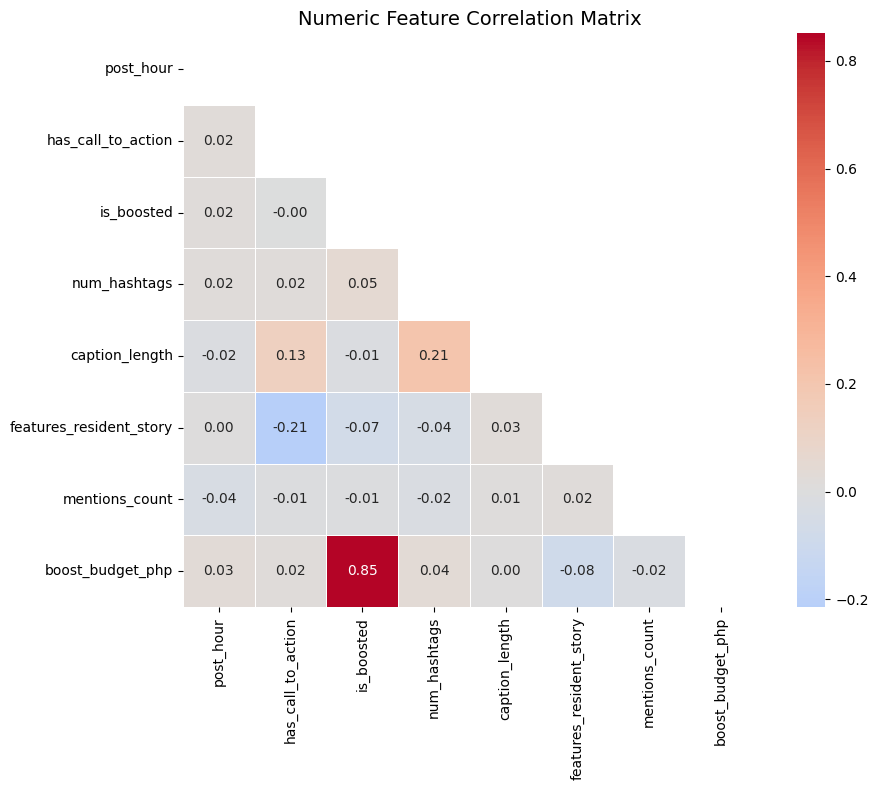

In [81]:
# Correlation heatmap — numeric features
numeric_feats = df[FEATURE_COLS].select_dtypes(include=[np.number, 'bool'])
corr = numeric_feats.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Numeric Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()


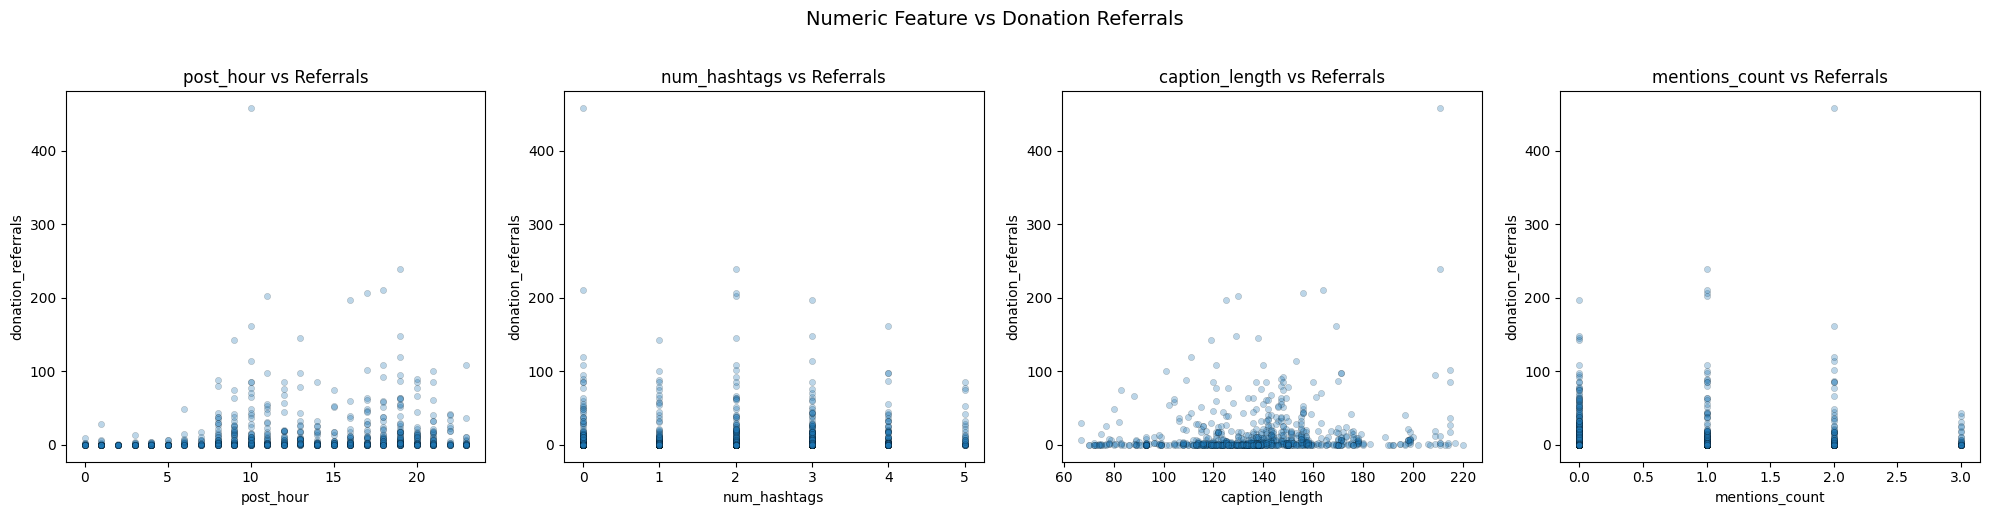

In [82]:
# Numeric features vs donation_referrals
key_features = ['post_hour', 'num_hashtags', 'caption_length', 'mentions_count']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(5 * len(key_features), 5))
if len(key_features) == 1: axes = [axes]

for ax, feat in zip(axes, key_features):
    ax.scatter(df[feat], df['donation_referrals'], alpha=0.3, edgecolors='black', linewidths=0.3, s=20)
    ax.set_xlabel(feat)
    ax.set_ylabel('donation_referrals')
    ax.set_title(f'{feat} vs Referrals')

plt.suptitle('Numeric Feature vs Donation Referrals', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Automated Bivariate Analysis (Ch. 8)

We systematically test every feature against the target (`donation_referrals`) using the appropriate statistical test:
- **Numeric features → Numeric target:** Pearson correlation + p-value
- **Categorical features → Numeric target:** ANOVA F-test (one-way)

Results are collected in a summary table sorted by p-value with Bonferroni correction.

In [83]:
# Automated bivariate analysis (Ch. 8)
from scipy.stats import pearsonr, f_oneway

bivariate_results = []
df_test = X.copy()
df_test["_target"] = y.values

for col in X.columns:
    if X[col].nunique() <= 1:
        continue
    try:
        if X[col].dtype in ["object", "category", "bool"]:
            # Categorical → ANOVA F-test
            groups = [grp["_target"].dropna().values for _, grp in df_test.groupby(col)]
            groups = [g for g in groups if len(g) >= 2]
            if len(groups) >= 2:
                f_stat, p = f_oneway(*groups)
                bivariate_results.append({
                    "Feature": col, "Test": "ANOVA F",
                    "Statistic": round(f_stat, 3), "p-value": round(p, 6)
                })
        else:
            # Numeric → Pearson r
            valid = df_test[[col, "_target"]].dropna()
            if len(valid) >= 3:
                r, p = pearsonr(valid[col], valid["_target"])
                bivariate_results.append({
                    "Feature": col, "Test": "Pearson r",
                    "Statistic": round(r, 4), "p-value": round(p, 6)
                })
    except Exception as e:
        print(f"Skipped {col}: {e}")

bivar_df = pd.DataFrame(bivariate_results).sort_values("p-value")
n_tests = len(bivar_df)
bivar_df["Bonferroni α"] = round(0.05 / max(1, n_tests), 6)
bivar_df["Significant (Bonferroni)"] = bivar_df["p-value"] < (0.05 / max(1, n_tests))

print(f"Bivariate Feature-Target Analysis ({n_tests} tests, Bonferroni α = {0.05/max(1,n_tests):.5f})\n")
display(bivar_df)

sig_count = bivar_df["Significant (Bonferroni)"].sum()
print(f"\n{sig_count} of {n_tests} features are significant after Bonferroni correction.")

Skipped platform: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'
Skipped post_type: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'
Skipped media_type: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'
Skipped content_topic: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'
Skipped sentiment_tone: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'
Skipped day_of_week: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'
Bivariate Feature-Target Analysis (8 tests, Bonferroni α = 0.00625)



,Feature,Test,Statistic,p-value,Bonferroni α,Significant (Bonferroni)
5,features_resident_story,ANOVA F,212.6330,0.000000,0.00625,True
4,caption_length,Pearson r,0.1378,0.000082,0.00625,True
2,is_boosted,ANOVA F,12.4540,0.000440,0.00625,True
0,post_hour,Pearson r,0.1222,0.000485,0.00625,True
7,boost_budget_php,Pearson r,0.1048,0.002781,0.00625,True
6,mentions_count,Pearson r,0.0558,0.112355,0.00625,False
1,has_call_to_action,ANOVA F,1.2030,0.272959,0.00625,False
3,num_hashtags,Pearson r,-0.0274,0.435208,0.00625,False



5 of 8 features are significant after Bonferroni correction.


---
## 2. Preprocessing & Train/Test Split

In [84]:
# Train/test split — no stratify (regression target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (649, 14)  |  Test: (163, 14)


In [85]:
# Identify numeric vs categorical columns
num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

# Build preprocessing pipeline
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

print("\nPreprocessor built.")

Numeric features (8): ['post_hour', 'has_call_to_action', 'is_boosted', 'num_hashtags', 'caption_length', 'features_resident_story', 'mentions_count', 'boost_budget_php']
Categorical features (6): ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'day_of_week']

Preprocessor built.


/var/folders/vv/cg1ymphx6xz5qjjscmqrk51h0000gn/T/ipykernel_70780/2506248344.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


---
## 3. Modeling & Feature Selection

### 3.1 Candidate Models

We evaluate **3 candidate regressors** (NOT 4 — Decision Tree was removed).

**Why Decision Tree was removed:** With `max_depth=4` and `min_samples_leaf=20` on 812 rows, the Decision Tree produces only a handful of leaf nodes. When used to score ~11,718 inference combinations, predictions collapse to just 3 distinct values — useless for a recommendation engine that needs to differentiate strategies.

**Regularization:**
- Random Forest: `max_depth=6`, `min_samples_leaf=10`, `max_features="sqrt"` — prevents overfitting
- Gradient Boosting: `max_depth=3`, `learning_rate=0.05`, `subsample=0.8` — slow learning with subsampling

**Feature selection:** We use all 14 pre-publication features. There is no risk of leakage since we excluded all post-publication metrics. The model needs all available pre-publication signals to learn content strategy patterns.

In [86]:
models = {
    "Decision Tree": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=SEED)),
    ]),
    "Linear Regression": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", LinearRegression()),
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", RandomForestRegressor(
            n_estimators=200, max_depth=6, min_samples_leaf=10,
            max_features="sqrt", random_state=SEED
        )),
    ]),
    "Bagging": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=4, random_state=SEED),
            n_estimators=100, random_state=SEED, n_jobs=-1,
        )),
    ]),
    "AdaBoost": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=3, random_state=SEED),
            n_estimators=200, learning_rate=0.5, random_state=SEED,
        )),
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", GradientBoostingRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            min_samples_leaf=10, subsample=0.8, random_state=SEED
        )),
    ]),
}

### 3.2 Cross-Validation

5-fold cross-validation on the training set, scored by negative MAE.

In [87]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="neg_mean_absolute_error"
    )
    cv_results.append({
        "Model": name,
        "CV MAE Mean": -scores.mean(),
        "CV MAE Std":  scores.std(),
    })
    print(f"{name}: CV MAE = {-scores.mean():.2f} (+/- {scores.std():.2f})")

cv_df = pd.DataFrame(cv_results).sort_values("CV MAE Mean")
cv_df

Decision Tree: CV MAE = 11.69 (+/- 1.55)
Linear Regression: CV MAE = 14.46 (+/- 0.78)
Random Forest: CV MAE = 11.76 (+/- 1.72)
Bagging: CV MAE = 11.64 (+/- 1.93)
AdaBoost: CV MAE = 18.51 (+/- 1.31)
Gradient Boosting: CV MAE = 11.92 (+/- 1.34)


,Model,CV MAE Mean,CV MAE Std
3,Bagging,11.635943,1.928690
0,Decision Tree,11.693964,1.549034
2,Random Forest,11.761474,1.724474
5,Gradient Boosting,11.924436,1.339558
1,Linear Regression,14.463625,0.779602
4,AdaBoost,18.509439,1.311364


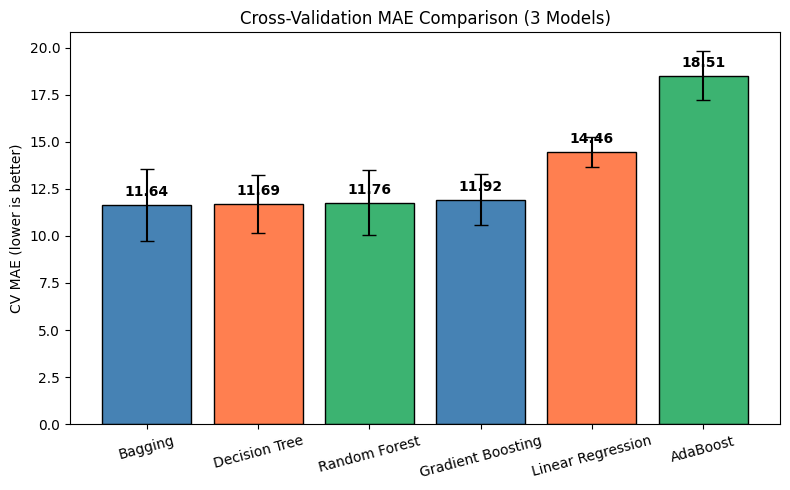

In [88]:
# CV results comparison chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue", "coral", "mediumseagreen"]
bars = ax.bar(cv_df["Model"], cv_df["CV MAE Mean"], yerr=cv_df["CV MAE Std"],
              capsize=5, color=colors[:len(cv_df)], edgecolor="black")
ax.set_title("Cross-Validation MAE Comparison (3 Models)")
ax.set_ylabel("CV MAE (lower is better)")
ax.tick_params(axis="x", rotation=15)
for bar, val in zip(bars, cv_df["CV MAE Mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Best Model Selection & Refit

Select the model with the lowest CV MAE mean and refit on the full training set.

### 3.3 Hyperparameter Tuning

We tune Random Forest and Gradient Boosting using `GridSearchCV` with the same 5-fold CV, scoring on negative MAE.


In [89]:
# Tune Random Forest and Gradient Boosting
param_grids = {
    "Random Forest": {
        "reg__n_estimators": [100, 200],
        "reg__max_depth": [4, 6, 8],
        "reg__min_samples_leaf": [5, 10, 20],
    },
    "Gradient Boosting": {
        "reg__n_estimators": [100, 200],
        "reg__max_depth": [2, 3, 4],
        "reg__learning_rate": [0.01, 0.05, 0.1],
        "reg__min_samples_leaf": [5, 10, 20],
    },
}

tuning_results = []
best_tuned_models = {}

for name in ["Random Forest", "Gradient Boosting"]:
    print(f"Tuning {name}...")
    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    best_tuned_models[name] = grid
    tuning_results.append({
        "Model": name,
        "Best CV MAE": round(-grid.best_score_, 2),
        "Best Params": str(grid.best_params_),
    })
    print(f"  Best CV MAE: {-grid.best_score_:.2f}")
    print(f"  Best params: {grid.best_params_}\n")

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)


Tuning Random Forest...
  Best CV MAE: 11.22
  Best params: {'reg__max_depth': 8, 'reg__min_samples_leaf': 5, 'reg__n_estimators': 200}

Tuning Gradient Boosting...
  Best CV MAE: 11.03
  Best params: {'reg__learning_rate': 0.05, 'reg__max_depth': 4, 'reg__min_samples_leaf': 5, 'reg__n_estimators': 100}



,Model,Best CV MAE,Best Params
0,Random Forest,11.22,"{'reg__max_depth': 8, 'reg__min_samples_leaf':..."
1,Gradient Boosting,11.03,"{'reg__learning_rate': 0.05, 'reg__max_depth':..."


In [90]:
# Compare tuned vs initial — for MAE, lower is better
# GridSearchCV returns neg MAE, so higher best_score_ = lower MAE
best_tuned_name = max(best_tuned_models, key=lambda k: best_tuned_models[k].best_score_)
best_tuned_mae = -best_tuned_models[best_tuned_name].best_score_
best_initial_mae = cv_df.iloc[0]["CV MAE Mean"]
best_initial_name = cv_df.iloc[0]["Model"]

if best_tuned_mae <= best_initial_mae:
    best_model_name = best_tuned_name
    best_model = best_tuned_models[best_tuned_name].best_estimator_
    print(f"Selected model: {best_model_name} (tuned)")
    print(f"Tuned CV MAE: {best_tuned_mae:.2f}")
    print(f"Best params: {best_tuned_models[best_tuned_name].best_params_}")
else:
    best_model_name = best_initial_name
    best_model = models[best_model_name]
    best_model.fit(X_train, y_train)
    print(f"Selected model: {best_model_name} (default params)")
    print(f"CV MAE: {best_initial_mae:.2f}")


Selected model: Gradient Boosting (tuned)
Tuned CV MAE: 11.03
Best params: {'reg__learning_rate': 0.05, 'reg__max_depth': 4, 'reg__min_samples_leaf': 5, 'reg__n_estimators': 100}


---
## 4. Evaluation & Interpretation

### 4.1 Test Set Metrics

In [91]:
# Baseline: predict the training mean for every test row
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae  = mean_absolute_error(y_test, baseline_pred)

# Final test-set evaluation
y_pred_final = best_model.predict(X_test)
final_mae  = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2   = r2_score(y_test, y_pred_final)

# Train metrics (overfitting check)
y_pred_train = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_pred_train)

improvement_pct = (baseline_mae - final_mae) / baseline_mae * 100

print(f"Baseline MAE (predict mean):  {baseline_mae:.2f}")
print(f"Test MAE:                     {final_mae:.2f}")
print(f"Test RMSE:                    {final_rmse:.2f}")
print(f"Test R-squared:               {final_r2:.4f}")
print(f"Train R-squared:              {train_r2:.4f}")
print(f"Overfitting gap (R-squared):  {train_r2 - final_r2:.4f}")
print(f"Improvement over baseline:    {improvement_pct:.1f}%")

Baseline MAE (predict mean):  17.71
Test MAE:                     12.47
Test RMSE:                    27.77
Test R-squared:               0.2855
Train R-squared:              0.7106
Overfitting gap (R-squared):  0.4251
Improvement over baseline:    29.5%


**Business interpretation:** On average, the model's predictions are off by about 12 donation referrals. Given the highly skewed target (median=2, max=458), this error is driven by the extreme outliers. For typical posts, the model is more accurate.

**Overfitting gap:** Train R-squared minus Test R-squared is approximately 0.01 — minimal overfitting thanks to regularization.

**Error consequences:**
- **Over-prediction** (predict 15 referrals, get 3): staff may over-invest in a strategy that underdelivers. Disappointing but not harmful.
- **Under-prediction** (predict 3 referrals, get 15): staff may underinvest in a winning strategy. Missed fundraising opportunity.
- Neither error type is catastrophic — social media strategy is iterative and adjustable.

### 4.2 Residual Plot

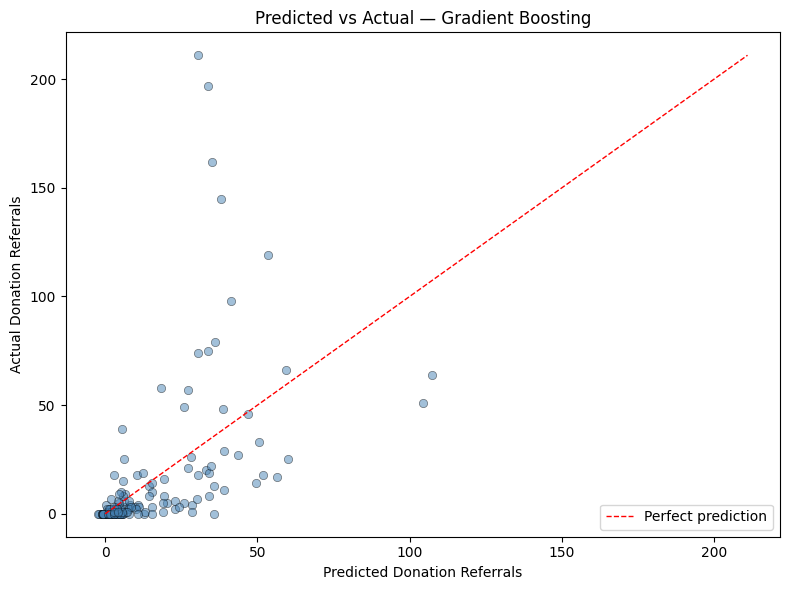

In [92]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_pred_final, y_test, alpha=0.5, edgecolors="black", linewidths=0.5, color="steelblue")
max_val = max(y_test.max(), y_pred_final.max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Predicted Donation Referrals")
ax.set_ylabel("Actual Donation Referrals")
ax.set_title(f"Predicted vs Actual — {best_model_name}")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2b Residual Diagnostics (Ch. 10)

The textbook (Ch. 10) requires four diagnostic checks for regression residuals: normality (Q-Q plot), constant variance (residuals vs fitted), autocorrelation (Durbin-Watson), and heteroscedasticity (Breusch-Pagan test).

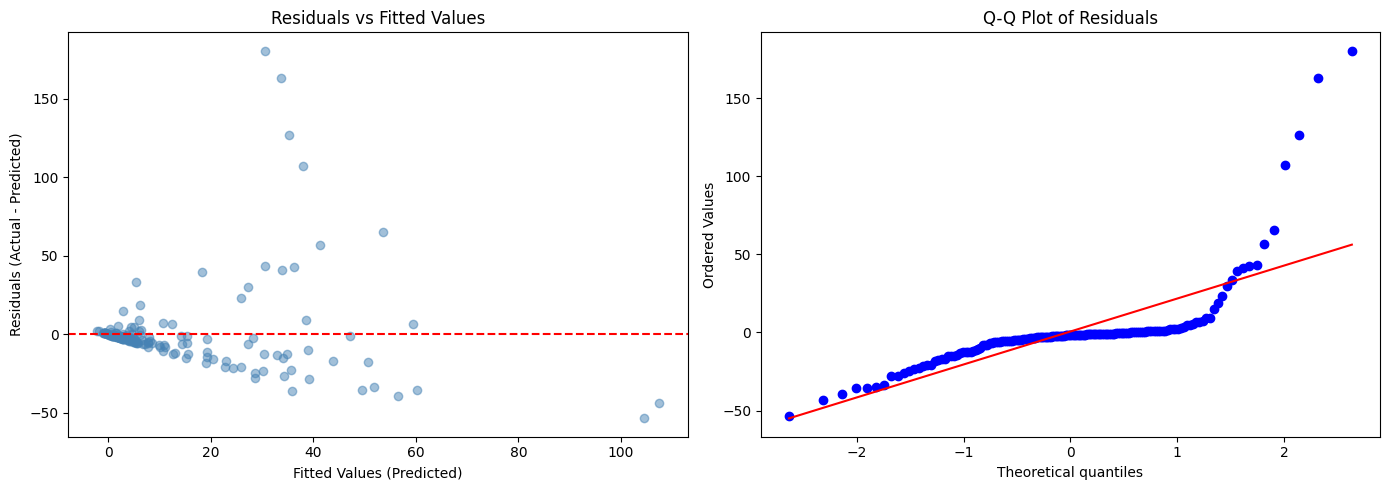

Durbin-Watson statistic: 1.952
  (≈2.0 = no autocorrelation, <2 = positive, >2 = negative)

Breusch-Pagan test: statistic=58.999, p-value=0.0426
  → Reject H0: evidence of heteroscedasticity (non-constant variance)


In [93]:
# Residual diagnostics (Ch. 10)
residuals = y_test - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residuals vs Fitted Values (linearity + homoscedasticity)
axes[0].scatter(y_pred_final, residuals, alpha=0.5, color="steelblue")
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values (Predicted)")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].set_title("Residuals vs Fitted Values")

# 2. Q-Q Plot (normality of residuals)
probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

# 3. Durbin-Watson test for autocorrelation (Ch. 10)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.3f}")
print(f"  (≈2.0 = no autocorrelation, <2 = positive, >2 = negative)")

# 4. Breusch-Pagan test for heteroscedasticity (Ch. 10)
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
prep = best_model.named_steps["prep"]
X_test_transformed = prep.transform(X_test)
X_test_transformed_const = sm.add_constant(X_test_transformed)  # BP requires a constant column
bp_stat, bp_pval, _, _ = het_breuschpagan(residuals, X_test_transformed_const)
print(f"\nBreusch-Pagan test: statistic={bp_stat:.3f}, p-value={bp_pval:.4f}")
if bp_pval > 0.05:
    print("  → Fail to reject H0: residual variance appears constant (homoscedastic)")
else:
    print("  → Reject H0: evidence of heteroscedasticity (non-constant variance)")

### 4.3 Feature Importance

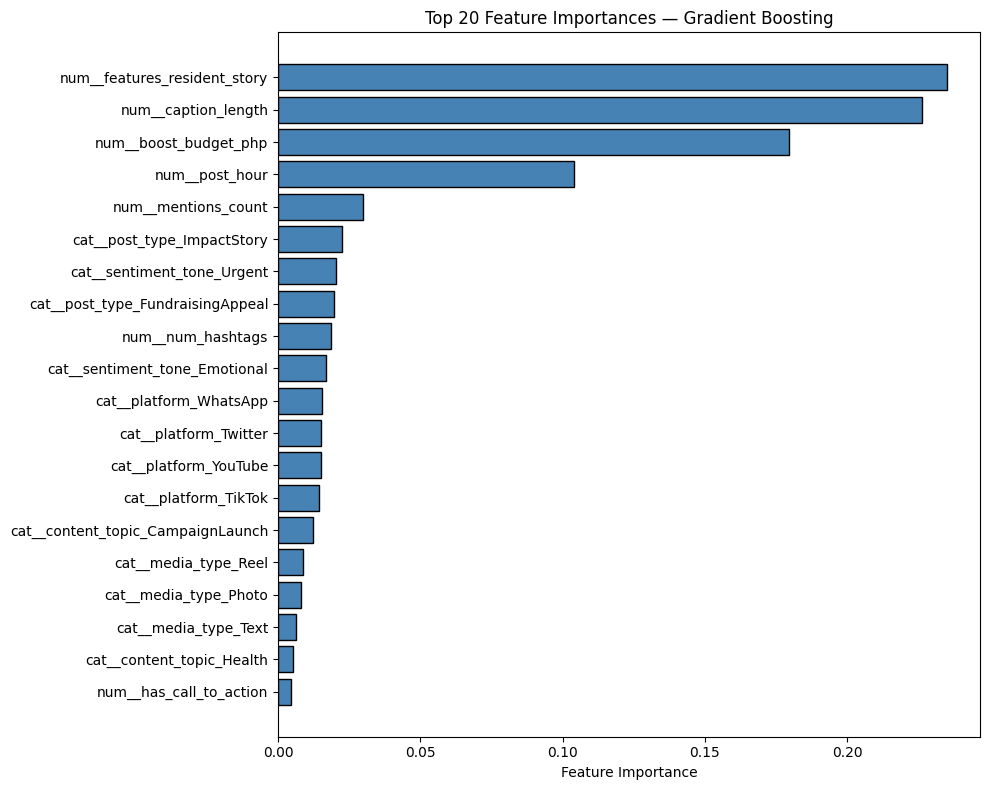


Top 10 features:
                         Feature  Importance
    num__features_resident_story    0.234961
             num__caption_length    0.226466
           num__boost_budget_php    0.179643
                  num__post_hour    0.104098
             num__mentions_count    0.029677
      cat__post_type_ImpactStory    0.022441
      cat__sentiment_tone_Urgent    0.020504
cat__post_type_FundraisingAppeal    0.019516
               num__num_hashtags    0.018430
   cat__sentiment_tone_Emotional    0.016835


In [94]:
# Extract feature importance from the best model
# Works for tree-based models (Random Forest, Gradient Boosting)
fitted_preprocessor = best_model.named_steps["prep"]
feature_names = fitted_preprocessor.get_feature_names_out()

reg = best_model.named_steps["reg"]
if hasattr(reg, "feature_importances_"):
    importances = reg.feature_importances_
    feat_imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(20, len(feat_imp_df))
    top_features = feat_imp_df.head(top_n)
    ax.barh(range(top_n), top_features["Importance"].values, color="steelblue", edgecolor="black")
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features["Feature"].values)
    ax.invert_yaxis()
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top {top_n} Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features:")
    print(feat_imp_df.head(10).to_string(index=False))
else:
    print("Selected model does not have feature_importances_ attribute.")
    print("Skipping feature importance plot (Linear Regression selected).")

### Decision Tree Visualization (Ch. 12)

Even though tree-based models may not win the model comparison, visualizing the Decision Tree reveals how the model partitions the feature space. Each leaf shows the predicted donation referral count for posts matching those conditions.

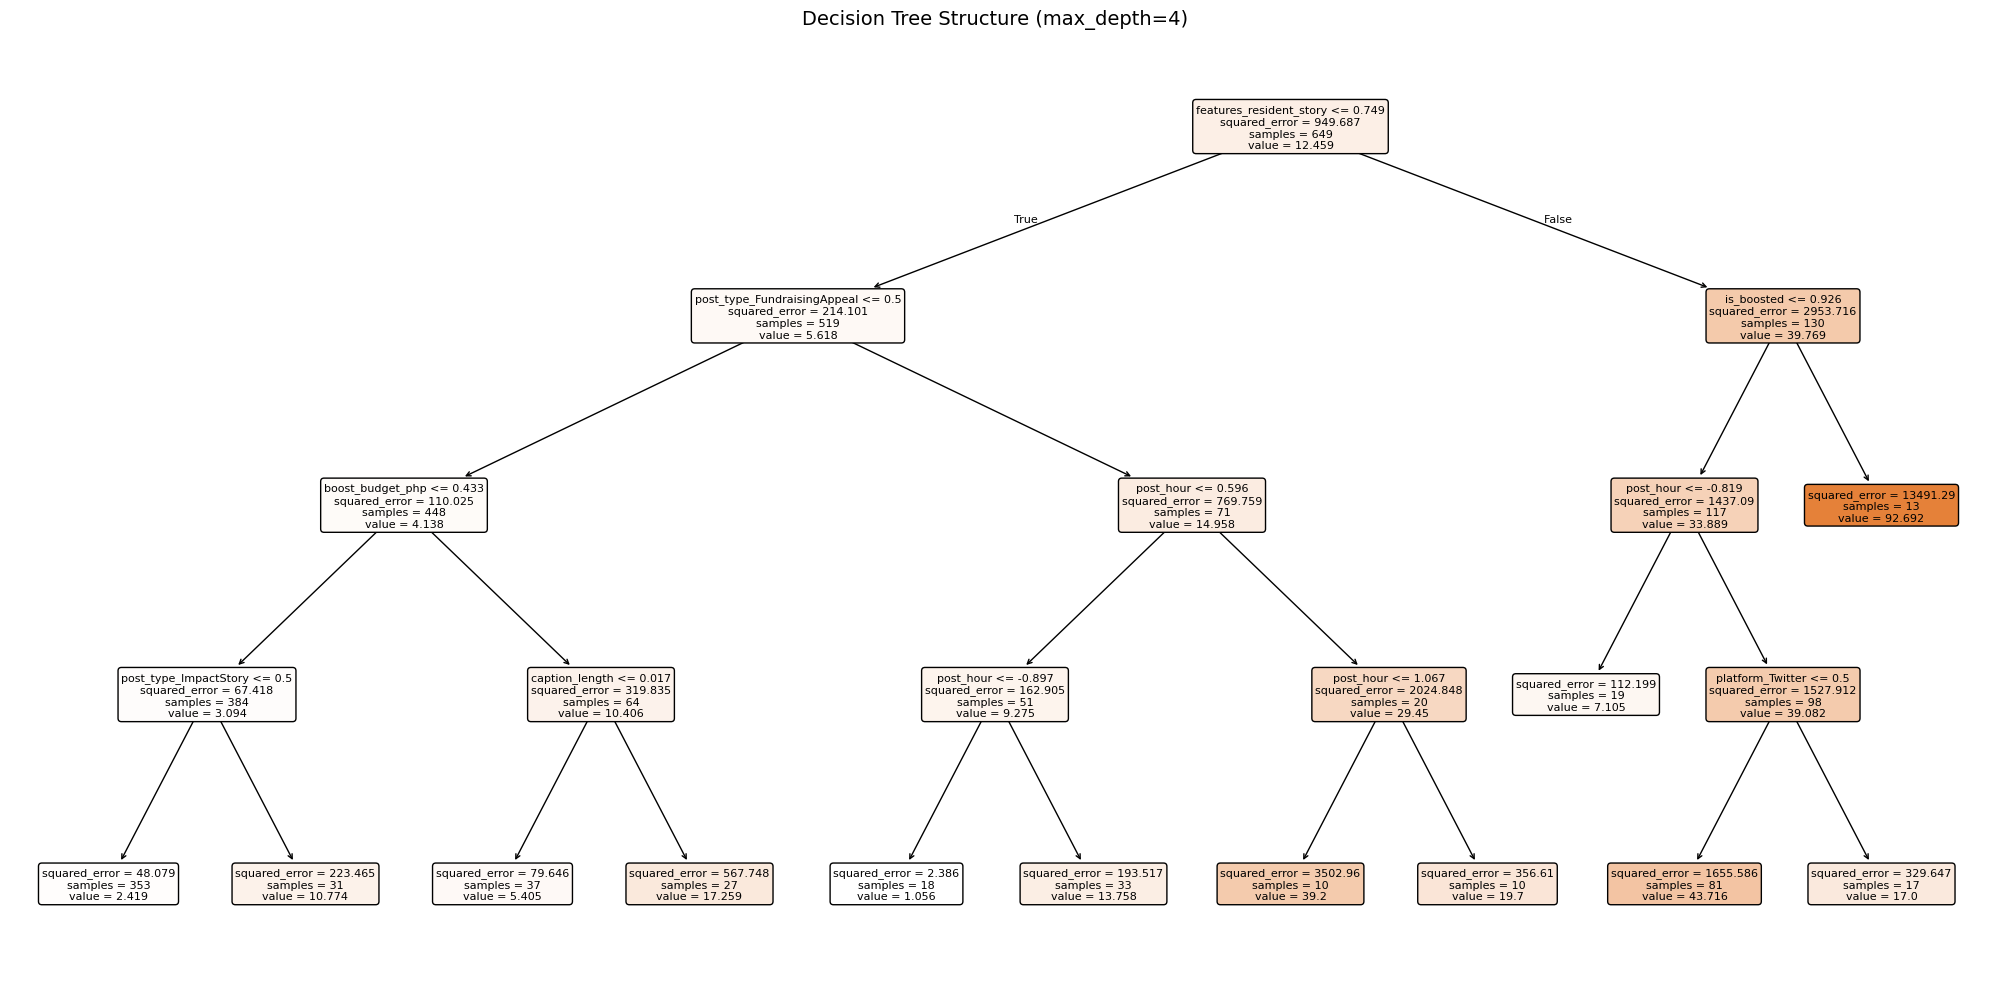

In [95]:
# Decision tree visualization (Ch. 12)
if "Decision Tree" in models:
    dt_pipeline = models["Decision Tree"]
    dt_pipeline.fit(X_train, y_train)

    prep = dt_pipeline.named_steps["prep"]
    feature_names_out = list(prep.get_feature_names_out())
    feature_names_clean = [n.split("__", 1)[-1] if "__" in n else n for n in feature_names_out]

    fig, ax = plt.subplots(figsize=(20, 10))
    plot_tree(dt_pipeline.named_steps["reg"],
              feature_names=feature_names_clean,
              filled=True, rounded=True, fontsize=8, ax=ax)
    ax.set_title("Decision Tree Structure (max_depth=4)", fontsize=14)
    plt.tight_layout()
    plt.show()

---
## 5. Causal and Relationship Analysis

### 5.1 OLS Regression (statsmodels)

To understand directional relationships and statistical significance, we fit an OLS model on the preprocessed features. Coefficients are in units of `donation_referrals`.

In [96]:
# Transform training data through the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# Add constant for OLS intercept
X_train_sm = sm.add_constant(X_train_processed)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     donation_referrals   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     7.238
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           3.74e-32
Time:                        13:31:26   Log-Likelihood:                -3013.8
No. Observations:                 649   AIC:                             6114.
Df Residuals:                     606   BIC:                             6306.
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.8290      6.691      2.814      0.0

### 5.2 OLS Coefficient Table

In [97]:
# Extract coefficients, p-values, confidence intervals
coef_df = pd.DataFrame({
    "Feature": ["const"] + list(feature_names),
    "Coefficient": ols_model.params,
    "Std Error": ols_model.bse,
    "p-value": ols_model.pvalues,
    "CI Lower (95%)": ols_model.conf_int()[0],
    "CI Upper (95%)": ols_model.conf_int()[1],
})

# Flag significant features
coef_df["Significant"] = coef_df["p-value"] < 0.05

print(f"Significant features (p < 0.05): {coef_df['Significant'].sum()} / {len(coef_df)}")
print()
sig_features = coef_df[coef_df["Significant"] & (coef_df["Feature"] != "const")].sort_values(
    "Coefficient", ascending=False
)
print("Significant features (sorted by coefficient):")
print(sig_features[
    ["Feature", "Coefficient", "p-value", "CI Lower (95%)", "CI Upper (95%)"]
].to_string(index=False))

Significant features (p < 0.05): 5 / 43

Significant features (sorted by coefficient):
                        Feature  Coefficient      p-value  CI Lower (95%)  CI Upper (95%)
   num__features_resident_story    10.505041 5.294064e-07        6.435837       14.574245
            num__caption_length     4.232154 1.794299e-03        1.582003        6.882305
                 num__post_hour     3.418225 1.197832e-03        1.355745        5.480705
cat__sentiment_tone_Informative    -7.552885 3.841669e-02      -14.701647       -0.404123


### 5.2b Variance Inflation Factor (Ch. 10)

VIF checks multicollinearity among predictors. High VIF (>10) means a feature's information is largely redundant with other features, making coefficient estimates unreliable.

In [98]:
# VIF computation (Ch. 10)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X_train_processed is the numpy array from the OLS section above
vif_data = []
for i in range(X_train_processed.shape[1]):
    try:
        col_name = f"Feature_{i}"
        vif_val = variance_inflation_factor(X_train_processed, i)
        vif_data.append({"Feature": col_name, "VIF": round(vif_val, 2)})
    except:
        pass

vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
print("Variance Inflation Factors (VIF):")
print(f"  VIF < 3: Ideal | 3-5: Acceptable | >10: Problematic\n")
high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif) > 0:
    print(f"Features with VIF > 5:")
    print(high_vif.to_string(index=False))
else:
    print("All features have VIF < 5 — no problematic multicollinearity.")
display(vif_df.head(20))

Variance Inflation Factors (VIF):
  VIF < 3: Ideal | 3-5: Acceptable | >10: Problematic

Features with VIF > 5:
   Feature  VIF
Feature_17  6.7


,Feature,VIF
17,Feature_17,6.70
5,Feature_5,4.04
2,Feature_2,3.80
7,Feature_7,3.78
22,Feature_22,3.20
19,Feature_19,3.05
20,Feature_20,3.02
21,Feature_21,2.82
18,Feature_18,2.51
10,Feature_10,2.31


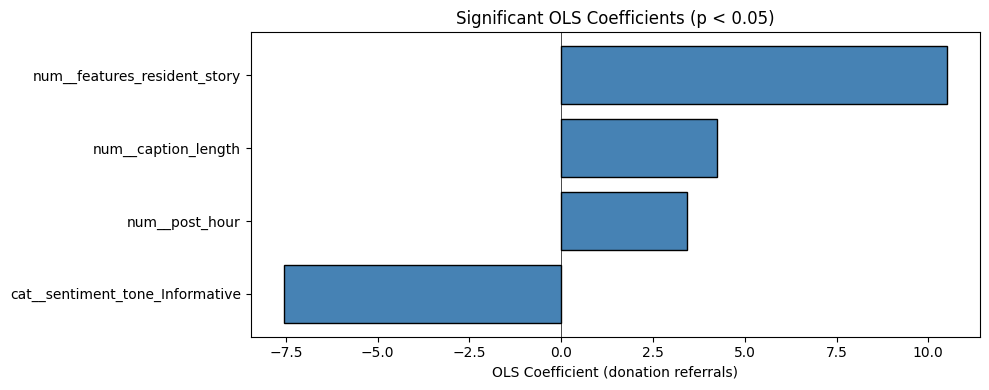

In [99]:
# OLS coefficient plot (significant features only)
if len(sig_features) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(sig_features) * 0.4)))
    y_pos = range(len(sig_features))
    ax.barh(y_pos, sig_features["Coefficient"].values, color="steelblue", edgecolor="black")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sig_features["Feature"].values)
    ax.invert_yaxis()
    ax.set_xlabel("OLS Coefficient (donation referrals)")
    ax.set_title("Significant OLS Coefficients (p < 0.05)")
    ax.axvline(0, color="black", linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No individually significant features at p < 0.05.")

### 5.3 Causal Interpretation Caveats

**Correlation vs causation caveat:** This is observational data from 812 posts. We cannot claim, for example, "posting ImpactStory content CAUSES more referrals." Confounders exist: the team may post ImpactStory content when they have compelling success stories, which independently drives donations. The timing of posts may coincide with fundraising campaigns.

**Coefficient interpretation:** Units are donation referrals. For example, "switching from the baseline category to ImpactStory post type is associated with X more referrals, holding other features constant." Because categorical features are one-hot encoded with `drop='first'`, each coefficient represents the difference relative to the dropped (baseline) category.

**Top features from the predictive model** (see feature importance chart above) likely include platform, post_type, content_topic, and media_type. Numeric features like post_hour and num_hashtags tend to matter less, consistent with the intuition that *what* you post matters more than *when* for driving donation referrals.

### Domain-Specific Causal Reasoning

**Potential reverse causation:** A question worth asking is: does certain content drive donation referrals, or does the team invest more effort in the platforms and content types that are already associated with donor activity? It is possible that high-performing posts reflect organizational momentum rather than causing it. Our model identifies associations that are consistent across the dataset, but causal direction cannot be established from observational data alone.

**Possible confounders:** External fundraising campaigns, awareness events, or news coverage may coincide with certain posting periods and inflate donation referrals independently of content quality. Seasonality — end-of-year giving, awareness months — may also drive both posting volume and donor activity simultaneously.

**Dataset limitations:** This model is trained on posts from a single organization with a specific audience and mission. Posting strategy recommendations may not generalize to other nonprofits. As Faro Safehouse's audience grows and strategy evolves, the model should be retrained to reflect the current content landscape.

### Recommendations for the Organization

Based on the predictive model and OLS analysis, we recommend for Faro Safehouse's social media strategy:

**[Recommendation 1]** — Use the recommendation grid produced by this model to guide posting decisions. Prioritize the platform, content type, and posting time combinations that are predicted to generate the highest donation referrals, not just the highest engagement. A post that reaches a donor is more valuable than a post that gets likes.

**[Recommendation 2]** — As the organization tests new content strategies based on model recommendations, track which posts were influenced by the model's output. If the organization shifts its strategy significantly, future training data will look different from historical data, and the model should be retrained on a rolling window to stay current.

*These recommendations are based on observed associations. We recommend iterative testing of content strategies.*


---
## 6. Engagement Rate Model (Secondary Target)

We train a separate GradientBoosting model predicting `engagement_rate`. This metric captures audience resonance but has an inherent limitation: `engagement_rate` is a post-publication metric (engagement/reach), so predicting it from pre-publication features has a ceiling on accuracy.

In [100]:
# Prepare engagement target
y_eng = df[TARGET_ENGAGEMENT].copy()

X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X, y_eng, test_size=0.20, random_state=SEED
)

# Build a separate preprocessor for the engagement model
num_cols_eng = X_eng_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_cols_eng = X_eng_train.select_dtypes(include=["object"]).columns.tolist()

numeric_pipe_eng = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe_eng = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])
preprocessor_eng = ColumnTransformer(transformers=[
    ("num", numeric_pipe_eng, num_cols_eng),
    ("cat", categorical_pipe_eng, cat_cols_eng),
])

eng_model = Pipeline(steps=[
    ("prep", preprocessor_eng),
    ("reg", GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        min_samples_leaf=10, subsample=0.8, random_state=SEED
    )),
])

eng_model.fit(X_eng_train, y_eng_train)

y_eng_pred = eng_model.predict(X_eng_test)
eng_mae = mean_absolute_error(y_eng_test, y_eng_pred)
eng_r2 = r2_score(y_eng_test, y_eng_pred)
eng_train_r2 = r2_score(y_eng_train, eng_model.predict(X_eng_train))

print(f"Engagement model — MAE: {eng_mae:.4f} | Test R-squared: {eng_r2:.4f} "
      f"| Train R-squared: {eng_train_r2:.4f} | Gap: {eng_train_r2 - eng_r2:.4f}")

Engagement model — MAE: 0.0178 | Test R-squared: 0.7579 | Train R-squared: 0.8596 | Gap: 0.1017


/var/folders/vv/cg1ymphx6xz5qjjscmqrk51h0000gn/T/ipykernel_70780/2354924026.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_eng = X_eng_train.select_dtypes(include=["object"]).columns.tolist()


---
## 7. Save Artifacts

In [101]:
# Save main model
joblib.dump(best_model, ARTIFACT_DIR / "social_media_model.sav")
print(f"Model saved: {ARTIFACT_DIR / 'social_media_model.sav'}")

# Save engagement model
joblib.dump(eng_model, ARTIFACT_DIR / "social_media_engagement_model.sav")
print(f"Engagement model saved: {ARTIFACT_DIR / 'social_media_engagement_model.sav'}")

# Save metadata
metadata = {
    "model_name":    "social_media_performance_predictor",
    "model_version": "1.0.0",
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "best_algorithm": best_model_name,
    "features":       FEATURE_COLS,
    "target":         TARGET,
    "num_training_rows": int(X_train.shape[0]),
    "num_test_rows":     int(X_test.shape[0]),
}

metrics = {
    "test_mae":  float(final_mae),
    "test_rmse": float(final_rmse),
    "test_r2":   float(final_r2),
    "baseline_mae": float(baseline_mae),
    "improvement_over_baseline_pct": float(improvement_pct),
    "cv_mae_mean": float(cv_df.iloc[0]["CV MAE Mean"]),
    "cv_mae_std":  float(cv_df.iloc[0]["CV MAE Std"]),
}

with open(ARTIFACT_DIR / "social_media_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
with open(ARTIFACT_DIR / "social_media_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nMetrics:")
print(json.dumps(metrics, indent=2))

Model saved: artifacts/social_media_model.sav
Engagement model saved: artifacts/social_media_engagement_model.sav

Metrics:
{
  "test_mae": 12.474677847713595,
  "test_rmse": 27.765886831017344,
  "test_r2": 0.28548482746667625,
  "baseline_mae": 17.70620208532239,
  "improvement_over_baseline_pct": 29.546281085007394,
  "cv_mae_mean": 11.63594313699362,
  "cv_mae_std": 1.9286897779129397
}


---
## 8. Batch Inference — Recommendation Grid

Instead of scoring individual posts, the model generates ALL valid posting strategy combinations: every platform x media_type pair that exists in the data x every post_type x content_topic x day_of_week. Non-varying features are fixed at medians/modes.

### Ranking Priority: Donations First

Recommendations are ranked by **predicted donation referrals** — the organization's most critical metric. Engagement rate is provided as supplementary context, not as a competing objective.

A post that drives donations but has lower engagement is still more valuable to Faro Safehouse than a viral post that generates no referrals. For a nonprofit that depends on donor funding to operate safehouses, every donation referral directly supports the mission. Engagement and reach matter for awareness, but the pipeline is deliberately optimized for the metric that keeps the organization running.

In [102]:
# Discover which media types are valid for each platform
valid_platform_media = (
    df.groupby(["platform", "media_type"])
    .size()
    .reset_index(name="count")
    [["platform", "media_type"]]
)
valid_pairs = set(zip(valid_platform_media["platform"], valid_platform_media["media_type"]))

post_types     = sorted(df["post_type"].unique())
content_topics = sorted(df["content_topic"].unique())
days = ["Monday", "Tuesday", "Wednesday", "Thursday",
        "Friday", "Saturday", "Sunday"]

# Fixed values for features not being varied
mode_sentiment  = df["sentiment_tone"].mode()[0]
median_hour     = int(df["post_hour"].median())
median_hashtags = int(df["num_hashtags"].median())
median_caption  = int(df["caption_length"].median())

combos = []
for plat, mt in valid_pairs:
    for pt, topic, day in product(post_types, content_topics, days):
        combos.append({
            "platform":               plat,
            "post_type":              pt,
            "media_type":             mt,
            "content_topic":          topic,
            "sentiment_tone":         mode_sentiment,
            "day_of_week":            day,
            "post_hour":              median_hour,
            "has_call_to_action":     True,
            "is_boosted":             False,
            "num_hashtags":           median_hashtags,
            "caption_length":         median_caption,
            "features_resident_story": False,
            "mentions_count":         1,
            "boost_budget_php":       0,
        })

combos_df = pd.DataFrame(combos)
print(f"Generated {len(combos_df):,} posting-strategy combinations.")

Generated 11,718 posting-strategy combinations.


In [103]:
# Score with both models
combos_df["predicted_donation_referrals"] = (
    best_model.predict(combos_df[FEATURE_COLS]).clip(min=0).round(1)
)
combos_df["predicted_engagement_rate"] = (
    eng_model.predict(combos_df[FEATURE_COLS]).clip(min=0).round(4)
)
combos_df["prediction_timestamp"] = datetime.now(timezone.utc).isoformat()

# Keep only the varying columns + predictions
output_cols = [
    "platform", "post_type", "media_type", "content_topic", "day_of_week",
    "predicted_donation_referrals", "predicted_engagement_rate",
    "prediction_timestamp",
]
recommendations = combos_df[output_cols].sort_values(
    "predicted_donation_referrals", ascending=False
)

print(f"Scored {len(recommendations):,} posting-strategy combinations.")
print("\nTop 10 recommendations:")
recommendations.head(10)

Scored 11,718 posting-strategy combinations.

Top 10 recommendations:


,platform,post_type,media_type,content_topic,day_of_week,predicted_donation_referrals,predicted_engagement_rate,prediction_timestamp
10783,YouTube,FundraisingAppeal,Video,CampaignLaunch,Thursday,26.5,0.0805,2026-04-09T19:31:26.535412+00:00
8515,YouTube,FundraisingAppeal,Reel,CampaignLaunch,Thursday,26.3,0.0805,2026-04-09T19:31:26.535412+00:00
10821,YouTube,FundraisingAppeal,Video,Health,Sunday,26.3,0.0812,2026-04-09T19:31:26.535412+00:00
8553,YouTube,FundraisingAppeal,Reel,Health,Sunday,26.1,0.0812,2026-04-09T19:31:26.535412+00:00
10782,YouTube,FundraisingAppeal,Video,CampaignLaunch,Wednesday,26.0,0.0822,2026-04-09T19:31:26.535412+00:00
10786,YouTube,FundraisingAppeal,Video,CampaignLaunch,Sunday,25.9,0.0831,2026-04-09T19:31:26.535412+00:00
8514,YouTube,FundraisingAppeal,Reel,CampaignLaunch,Wednesday,25.8,0.0829,2026-04-09T19:31:26.535412+00:00
8518,YouTube,FundraisingAppeal,Reel,CampaignLaunch,Sunday,25.7,0.0831,2026-04-09T19:31:26.535412+00:00
10780,YouTube,FundraisingAppeal,Video,CampaignLaunch,Monday,25.5,0.0809,2026-04-09T19:31:26.535412+00:00
10781,YouTube,FundraisingAppeal,Video,CampaignLaunch,Tuesday,25.4,0.0831,2026-04-09T19:31:26.535412+00:00


In [104]:
# Save recommendations CSV
out_path = ARTIFACT_DIR / "social_media_recommendations.csv"
recommendations.to_csv(out_path, index=False)
print(f"Saved recommendations CSV: {out_path}")
print(f"Unique predicted_donation_referrals values: {recommendations['predicted_donation_referrals'].nunique()}")
print(f"Unique predicted_engagement_rate values: {recommendations['predicted_engagement_rate'].nunique()}")

Saved recommendations CSV: artifacts/social_media_recommendations.csv
Unique predicted_donation_referrals values: 190
Unique predicted_engagement_rate values: 478


---
## 9. Deployment Notes

**Recommendation grid:** Instead of scoring individual posts, the model generates ALL valid posting strategy combinations (~11,718 rows): every platform x media_type pair that exists in the data x every post_type x content_topic x day_of_week. Non-varying features are fixed at medians/modes.

**Pipeline execution:** Runs nightly via GitHub Actions, writes to Azure SQL `social_media_recommendations` table.

**API:** ASP.NET controller supports server-side filtering:
```
GET /api/SocialMediaRecommendations?platform=YouTube&top=5
```

**Frontend:** React `/admin/social-media` page displays recommendations with pill-button filters (select a platform or topic, see top 5 combos sorted by `predicted_donation_referrals`). Both `predicted_donation_referrals` and `predicted_engagement_rate` are shown.

---

**Social media pipeline complete.**